For a learning rate of 0.0001, error threshold of 0.001 and intial guess for w1, w2 = 0, 0:-

Using Standard Gradient Descent: -
w1 = [2.01102227]
w2 = [0.9824846]
Total number of iterations =170
Total time taken =2.850334405899048


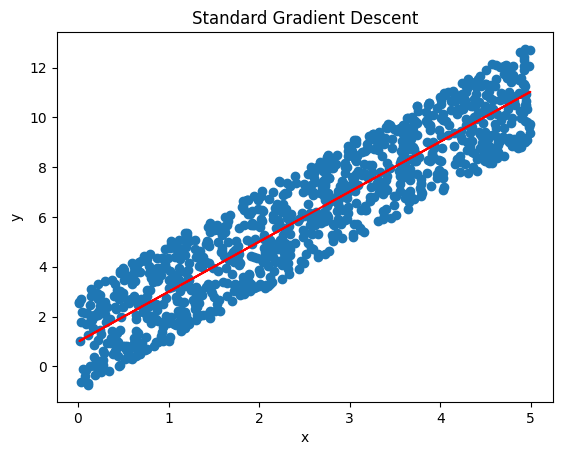


Using Stochastic Gradient Descent (batch size = 1): -
w1 = [2.00611849]
w2 = [0.99501416]
Total number of iterations =619000
Total time taken =14.562583208084106


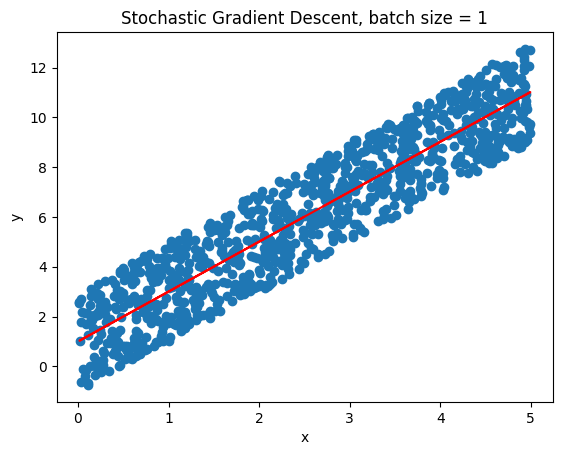


Using Stochastic Gradient Descent (batch size = 10): -
w1 = [2.0026271]
w2 = [1.00391729]
Total number of iterations =1644000
Total time taken =43.96433162689209


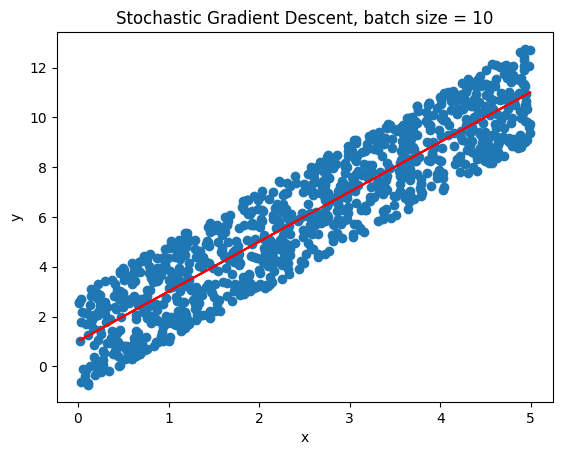

In [106]:
import numpy as np
import time
import pandas as pd
import random
import matplotlib.pyplot as plt

dat = pd.read_csv('/content/dataset.csv',header = None).values
x = dat[:,0:1]
y = dat[:,1:2]
N = 1000

s = 1e-4 #learning rate
eps = 1e-3 #error threshold
# Initial guess
w1_guess = 0
w2_guess = 0

def gradient(w1, w2):
  dw1 = 0.0
  dw2 = 0.0
  for i in range(N):
    y_pred = w1*x[i] + w2
    err = y[i] - y_pred
    dw1 += -2*x[i]*err
    dw2 += -2*err
  return dw1, dw2

def error(w1,w2):
  err_tot = 0
  for i in range(N):
    y_pred = w1*x[i] + w2
    err = y[i] - y_pred
    err_tot+=err
  return err_tot**2

def gradient_descent():
  iter = 0
  w1 = w1_guess
  w2 = w2_guess
  start = time.time()
  while error(w1,w2)>eps:
    dw1, dw2 = gradient(w1, w2)
    w1 -= s*dw1
    w2 -= s*dw2
    iter += 1
  end = time.time()
  return w1, w2, iter, end-start

def stochastic_gradient_descent():
  epochs = 0
  w1 = w1_guess
  w2 = w2_guess
  start = time.time()
  while error(w1,w2)>eps:
   for t in range(N):
    i = random.randint(0,N-1)
    y_pred = w1*x[i] + w2
    err = y[i] - y_pred
    dw1 = -2*x[i]*err
    dw2 = -2*err
    w1 -= s*dw1
    w2 -= s*dw2
   epochs += 1
  end = time.time()
  return w1, w2, epochs*N, end-start

def mini_batch_stochastic_gradient_descent():
  batch_size = 10
  epochs = 0
  w1 = w1_guess
  w2 = w2_guess
  start = time.time()
  while error(w1,w2)>eps:
   for t in range(N // batch_size):
    dw1 = 0
    dw2 = 0
    for i in range(batch_size):
     i = random.randint(0,N-1)
     y_pred = w1*x[i] + w2
     err = y[i] - y_pred
     dw1 += -2*x[i]*err
     dw2 += -2*err
     w1 -= s*dw1
     w2 -= s*dw2
   epochs += 1
  end = time.time()
  return w1, w2, epochs*(N // batch_size)*batch_size, end-start

w1_gd, w2_gd, iter_gd, time_gd = gradient_descent()

print('For a learning rate of ' + str(s) + ', error threshold of ' + str(eps) + ' and intial guess for w1, w2 = '+ str(w1_guess) + ', '+ str(w2_guess) + ':-')

print('\nUsing Standard Gradient Descent: -')
print('w1 = '+ str(w1_gd))
print('w2 = '+ str(w2_gd))
print('Total number of iterations = '+ str(iter_gd))
print('Total time taken = '+ str(time_gd))

plt.scatter(x,y)
plt.plot(x,w1_gd*x+w2_gd,color = 'red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard Gradient Descent')
plt.show()

w1_sgd, w2_sgd, iter_sgd, time_sgd = stochastic_gradient_descent()

print('\nUsing Stochastic Gradient Descent (batch size = 1): -')
print('w1 = '+ str(w1_sgd))
print('w2 = '+ str(w2_sgd))
print('Total number of iterations = '+ str(iter_sgd))
print('Total time taken = '+ str(time_sgd))

plt.scatter(x,y)
plt.plot(x,w1_sgd*x+w2_sgd,color = 'red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Stochastic Gradient Descent, batch size = 1')
plt.show()

w1_mbsgd, w2_mbsgd, iter_mbsgd, time_mbsgd = stochastic_gradient_descent()

print('\nUsing Stochastic Gradient Descent (batch size = 10): -')
print('w1 = '+ str(w1_mbsgd))
print('w2 = '+ str(w2_mbsgd))
print('Total number of iterations = '+ str(iter_mbsgd))
print('Total time taken = '+ str(time_mbsgd))

plt.scatter(x,y)
plt.plot(x,w1_mbsgd*x+w2_mbsgd,color = 'red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Stochastic Gradient Descent, batch size = 10')
plt.show()